# PlotSpectralLibraries

This notebook breaks down the `earthlib` spectral library on multiple levels and plots each spectra.

There are a series of land cover types represented in `earthlib`. As is the case with most typologies, there can be nested relationships between land cover types.

Other tools for working with spectral datasets (e.g. VIPER tools) characterize these patterns by organizing spectra by "levels." These can be arbitrarily complex at each level, and each spectrum is assigned a value for each level. In order to plot the spectra we'll use the level-2 labels.

In [1]:
import os
import numpy as np
from earthlib import library
import matplotlib as mpl
from matplotlib import colors
import matplotlib.pyplot as plt

# paths
plots = os.path.join(
    os.path.dirname(os.getcwd()), 
    'docs',
    'img'
)

# plot settings
figsize = (5, 5)
dpi = 125
facecolor = 'white'
ylim = [0.0, 0.66]

In [2]:
# helper functions
def block_water_bands(plot, zorder=3, ylim = None):
    regions = [[1.35, 1.46], [1.79, 1.96]]
    color = 'white'
    alpha = 1.0
    
    # get the plot ymin/ymax to fill between
    ylim = plot.get_ylim() if ylim is None else ylim
    ymins = [0, 0]
    ymaxs = [ylim[1], ylim[1]]
    
    for region in regions:
        plot.fill_between(
            region,
            ymins,
            ymaxs,
            color=color,
            alpha=alpha,
            #zorder=zorder,
        )

In [3]:
# show the different spectra types
levels = [f'LEVEL_{i}' for i in [1, 2, 3, 4]]
labels = []
for level in levels:
    unique = list(library.metadata[level].unique())
    print(f'{level}: {", ".join(unique)}')

LEVEL_1: pervious, impervious
LEVEL_2: bare, burned, npv, built, vegetation
LEVEL_3: soil, gravel, char, npv, bark, wood, litter, asphalt, comp_shingle, concrete_tile, driveway, glass, manhole, metal, other, paint, road, sidewalk, tile, wood_shingle, canopy
LEVEL_4: measured, simulated


## Multi-panel plot

Create a 3x2 panel plot with each of the level 2 classes, then with the mean of each one plotted together on the last panel.

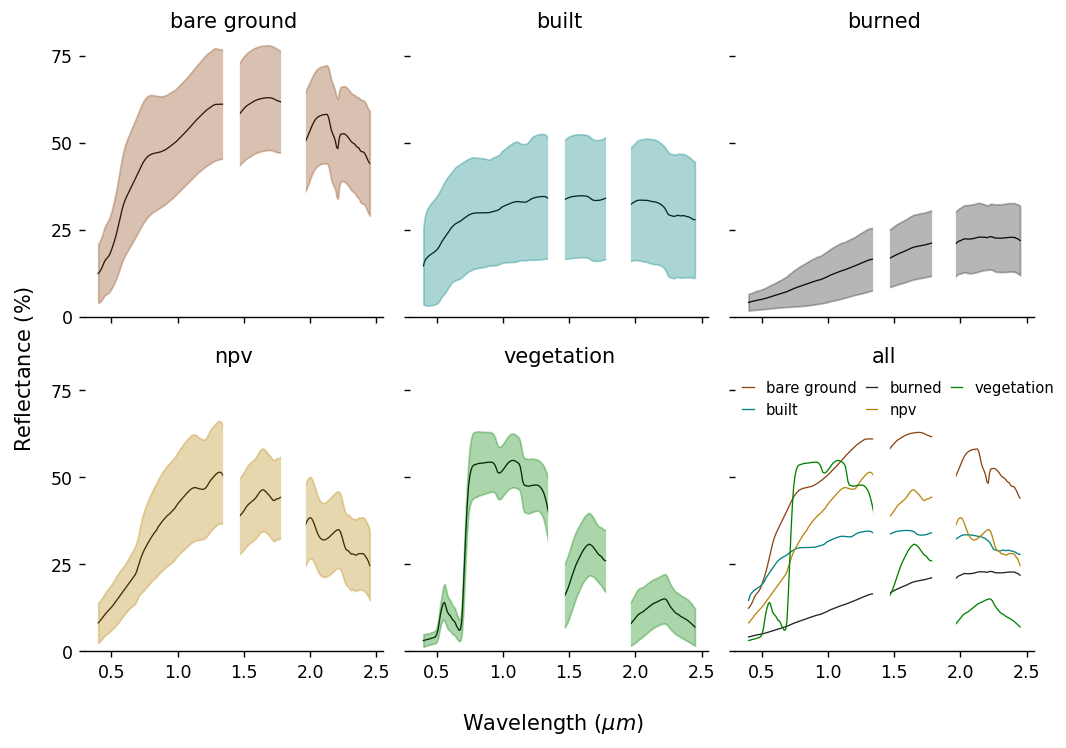

In [4]:
level = "LEVEL_2"
labels = list(library.metadata[level].unique())
labels.sort()
colors = ["saddlebrown", "teal", "#222222", "darkgoldenrod", "green"]
alpha = 0.33
wavelengths = library.sensor.band_centers
ylim = [0, 0.8]

figsize = (9, 6)
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    sharex=True,
    sharey=True,
    facecolor=facecolor,
    figsize=figsize,
    dpi=dpi,
)

axs = axs.ravel().tolist()
for label, color, ax in zip(labels, colors, axs):
    idx = library.metadata[level] == label
    spectra = library.data[idx,:]
    mean = spectra.mean(axis=0)
    stdv = spectra.std(axis=0)

    # plot the mean
    ax.plot(
        wavelengths,
        mean,
        color='black',
        linewidth=0.75,
        zorder=1,
    )
    
    # plot the variance
    ax.fill_between(
        wavelengths,
        mean - (1 * stdv),
        mean + (1 * stdv),
        color=color,
        alpha=alpha,
    )
    
    # overplot white boxes to mask water bands
    block_water_bands(ax, ylim=ylim)

    # remove borders
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # labels
    label = "bare ground" if label == "bare" else label
    ax.set_title(label)

    # plot means
    axs[-1].plot(wavelengths, mean, color=color, linewidth=0.75, label=label, zorder=1)

# mask water bands on mean plot
block_water_bands(axs[-1], ylim=ylim)
axs[-1].spines["right"].set_visible(False)
axs[-1].spines["top"].set_visible(False)
axs[-1].spines["left"].set_visible(False)

# scale and label
fig.supxlabel("Wavelength ($\mu m$)")
fig.supylabel("Reflectance ($\%$)")
plt.ylim(ylim)
plt.xticks([0.5, 1.0, 1.5, 2.0, 2.5])
plt.yticks([0, 0.25, 0.5, 0.75], [0, 25, 50, 75])
axs[-1].set_title('all')
axs[-1].legend(
    loc='upper left',
    ncols=3,
    fontsize=8.5,
    handlelength=0.8,
    frameon=False,
    columnspacing=0.6,
    borderpad=0,
    markerscale=20,
)
fig.tight_layout()

# save to disk
path = f"{plots}/mean-spectra-panels.png"
plt.savefig(path, dpi=dpi)

# Plotting individual spectra

This notebook creates small multiples of individual endmember spectra to demonstrate the range of types represented within each land cover type.

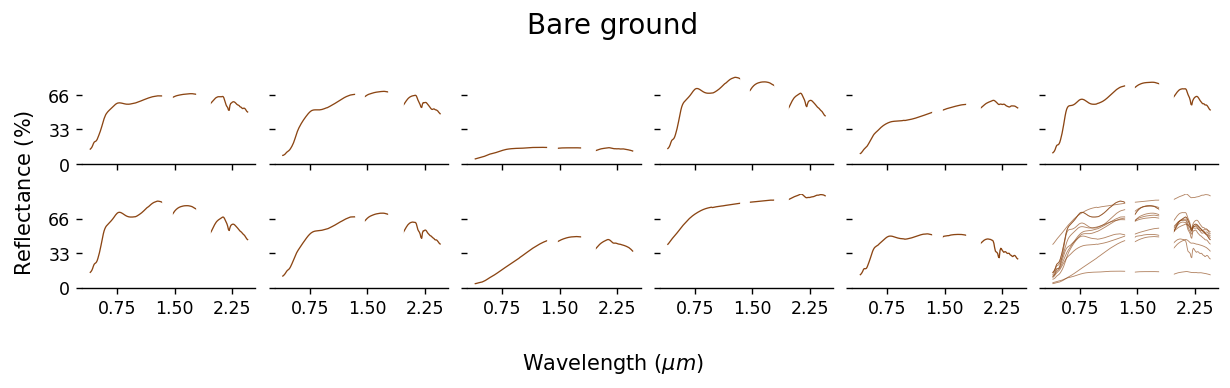

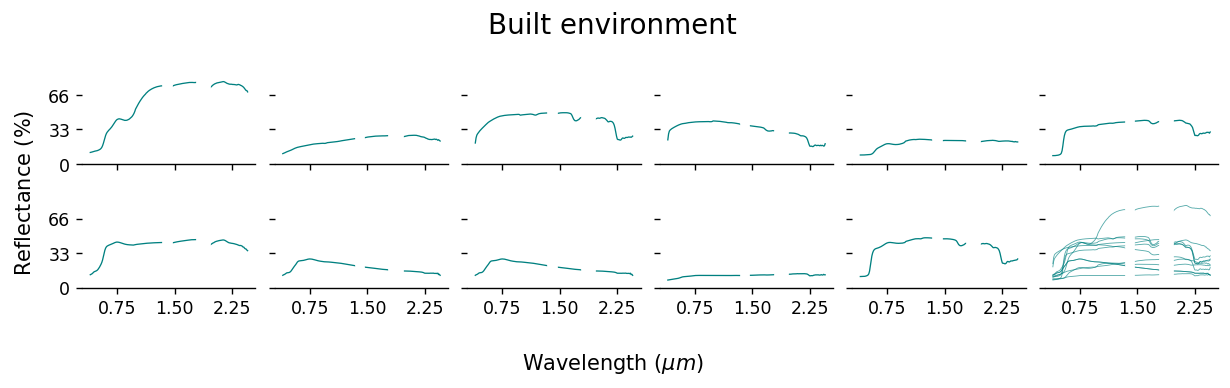

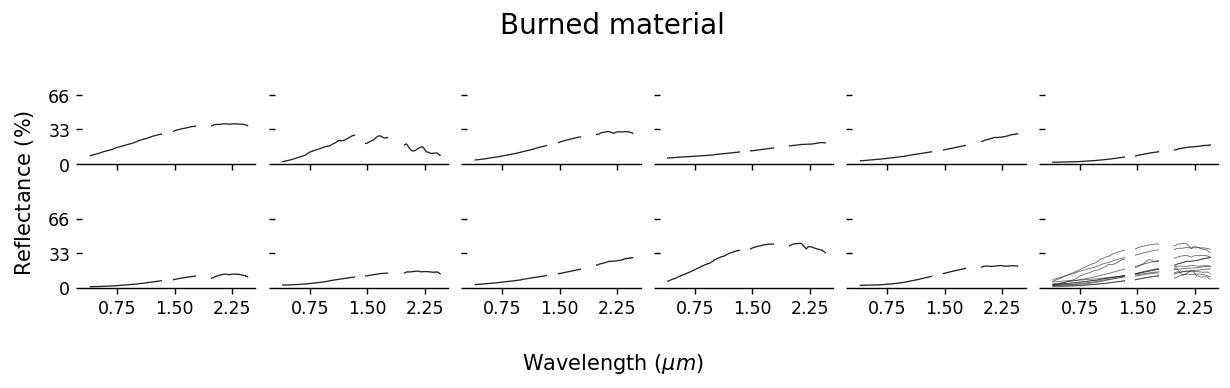

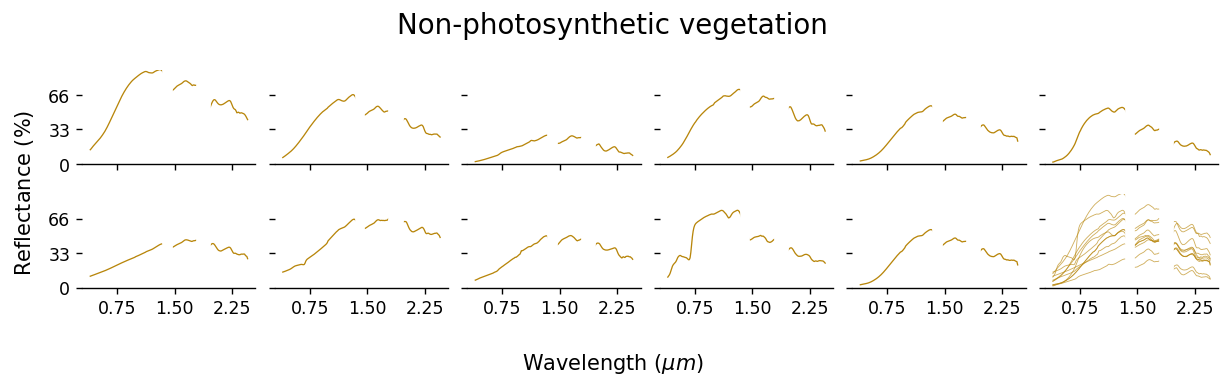

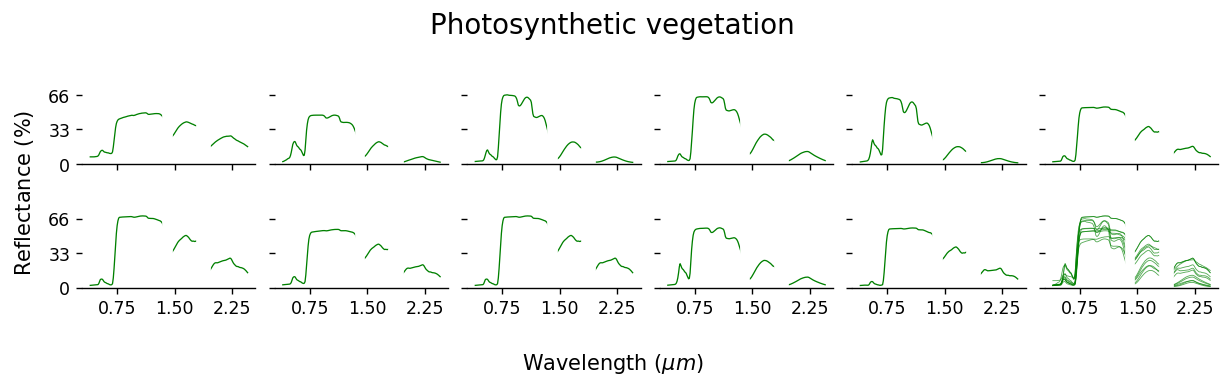

In [6]:
figsize = (10, 3)
ylim = (0, 0.9)

for label, color in zip(labels, colors):
    fig, axs = plt.subplots(
        nrows=2,
        ncols=6,
        sharex=True,
        sharey=True,
        facecolor=facecolor,
        figsize=figsize,
        dpi=dpi,
    )
    axs = axs.ravel().tolist()

    n_random = len(axs) - 1
    samples = library.subsample(n_random, by_type=label)
    
    for idx in range(n_random):
        spectra = samples.data[idx]
        ax = axs[idx]

        # line plot
        ax.plot(
            wavelengths,
            spectra,
            color=color,
            linewidth=0.75,
            zorder=1,
        )
        
        # overplot white boxes to mask water bands
        block_water_bands(ax, ylim=ylim)
    
        # remove borders
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["left"].set_visible(False)
    
        # plot means
        axs[-1].plot(wavelengths, spectra, color=color, linewidth=0.5, alpha=0.66, label=label, zorder=1)

    # mask water bands on mean plot
    block_water_bands(axs[-1], ylim=ylim)
    axs[-1].spines["right"].set_visible(False)
    axs[-1].spines["top"].set_visible(False)
    axs[-1].spines["left"].set_visible(False)
    
    # scale and label
    label = "non-photosynthetic vegetation" if label == "npv" else label
    label = "photosynthetic vegetation" if label == "vegetation" else label
    label = "built environment" if label == "built" else label
    label = "bare ground" if label == "bare" else label
    label = "burned material" if label == "burned" else label
    title = str.capitalize(label)

    fig.suptitle(title, fontsize=16)
    fig.supxlabel("Wavelength ($\mu m$)", fontsize=12)
    fig.supylabel("Reflectance ($\%$)", fontsize=12)
    plt.ylim(ylim)
    plt.xticks([0.75, 1.5, 2.25])
    plt.yticks([0, 0.33, 0.66], [0, 33, 66])
    fig.tight_layout()

    # save to disk
    path = f"{plots}/samples-{label.replace(' ', '-')}.png"
    plt.savefig(path, dpi=dpi)